# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
file_path = "../data/processed/prices_20250821-180122.parquet"
df = pd.read_parquet(file_path)
# inject a bit of missingness and outliers
df.head()

,date,aapl,VCNIX
0,2025-03-28,217.90,20.83
1,2025-03-31,222.13,20.83
2,2025-04-01,223.19,21.00
3,2025-04-02,223.89,21.16
4,2025-04-03,203.19,20.01


## 1) First look

In [18]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    100 non-null    object 
 1   aapl    100 non-null    float64
 2   VCNIX   100 non-null    float64
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


(None,
 date     0
 aapl     0
 VCNIX    0
 dtype: int64)

## 2) Numeric profile

In [19]:
desc = df[['date','aapl','VCNIX']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
aapl,100.0,207.2237,10.844364,172.42,200.3900,206.105,212.450,233.33,0.287010,0.863851
VCNIX,100.0,23.1220,1.947635,18.46,21.4375,23.470,24.745,25.78,-0.598927,-0.746295


## 3) Distributions (TODO: add at least 3)

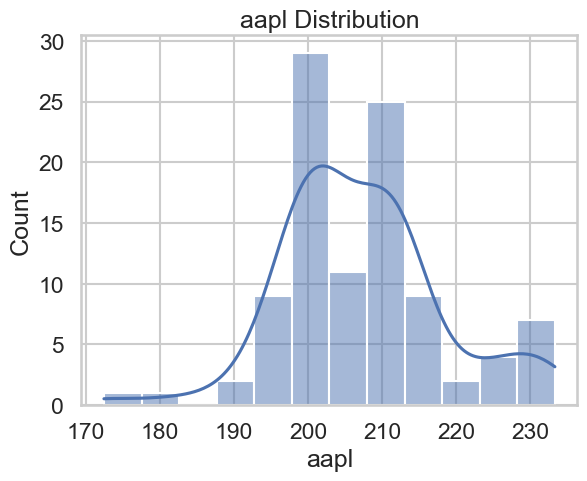

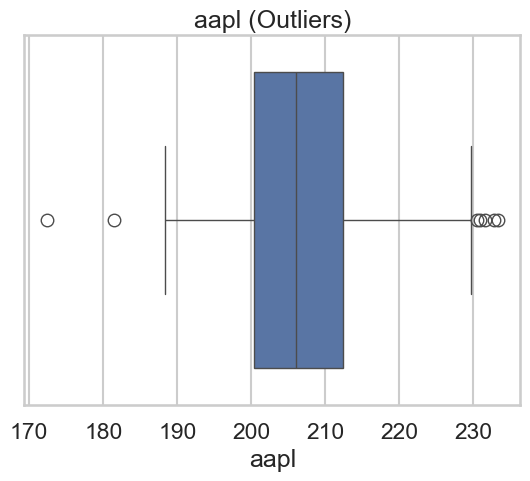

In [20]:
# TODO: histogram + KDE for a key variable
sns.histplot(df['aapl'], kde=True)
plt.title('aapl Distribution')
plt.show()

# TODO: boxplot for outliers
sns.boxplot(x=df['aapl'])
plt.title('aapl (Outliers)')
plt.show()

## 4) Relationships (TODO: add at least 2)

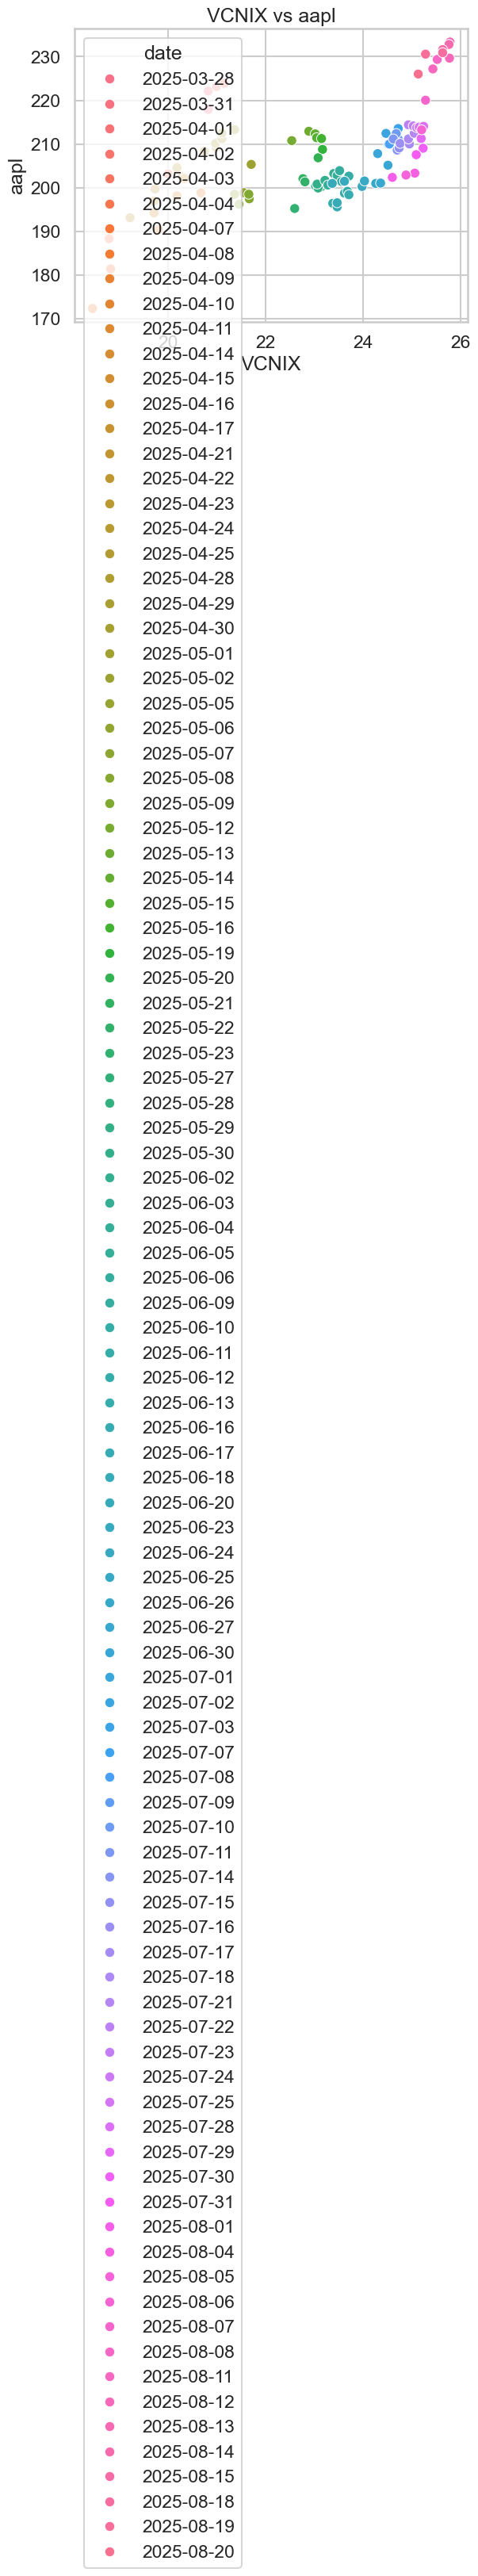

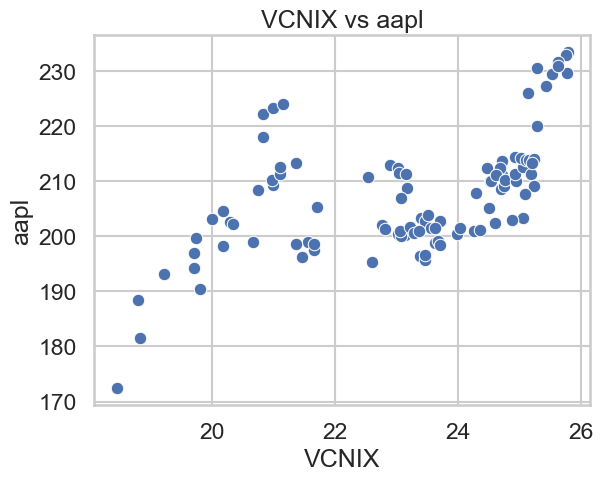

In [22]:
sns.scatterplot(data=df, x='VCNIX', y='aapl', hue='date')
plt.title('VCNIX vs aapl')
plt.show()

sns.scatterplot(data=df, x='VCNIX', y='aapl')
plt.title('VCNIX vs aapl')
plt.show()

## 5) (Optional) Correlation matrix

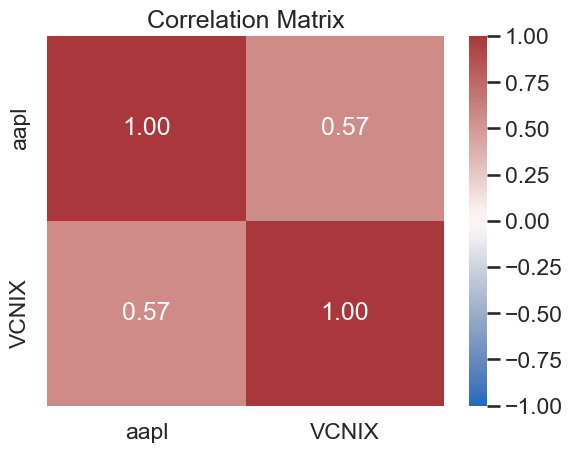

,aapl,VCNIX
aapl,1.000000,0.569465
VCNIX,0.569465,1.000000


In [23]:
corr = df[['date','aapl','VCNIX']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)

In [ ]:
## The datas are complete and in a good quality.
## AAPL stock price is likely to be positive correlated with Nasdaq 100.
## There are a few outliers of AAPL stock price, indicating the important days.

## Assumption: The stock price is roughly normal to detect the outliers.

## Fingding the features for the rolling mean of AAPL and its stock price ratio against Nasdaq 100.